In [1]:
# Import all Necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score, recall_score, f1_score, precision_score, mean_squared_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel('LALIGA_DATASET.xlsx')

In [3]:
df

,Season,Squad,FIFA OVR RATING,MP,TW,TD,TL,TGF,TGA,TGD,...,HW,HD,HL,HGF,HGA,AW,AD,AL,AGF,AGA
0,2023/2024,Real Madrid,85,38,29,8,1,87,26,61,...,16,3,0,48,9,13,5,1,39,17
1,2023/2024,Barcelona,84,38,26,7,5,79,44,35,...,15,1,3,43,21,11,6,2,36,23
2,2023/2024,Girona,79,38,25,6,7,85,46,39,...,15,2,2,53,20,10,4,5,32,26
3,2023/2024,Atlético Madrid,82,38,24,4,10,70,43,27,...,16,1,2,42,22,8,3,8,28,21
4,2023/2024,Athletic Club,80,38,19,11,8,61,37,24,...,12,6,1,42,18,7,5,7,19,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2014/2015,La Coruna,73,38,7,14,17,35,60,-25,...,5,6,8,22,30,2,8,9,13,30
196,2014/2015,Granada,73,38,7,14,17,29,64,-35,...,4,10,5,13,17,3,4,12,16,47
197,2014/2015,Eibar,72,38,9,8,21,34,55,-21,...,5,3,11,20,29,4,5,10,14,26
198,2014/2015,Almería,72,38,8,8,22,35,64,-29,...,3,7,9,20,28,5,1,13,15,36


## DATA ANALYSIS AND VISUALIZATION

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Season           200 non-null    object 
 1   Squad            200 non-null    object 
 2   FIFA OVR RATING  200 non-null    int64  
 3   MP               200 non-null    int64  
 4   TW               200 non-null    int64  
 5   TD               200 non-null    int64  
 6   TL               200 non-null    int64  
 7   TGF              200 non-null    int64  
 8   TGA              200 non-null    int64  
 9   TGD              200 non-null    int64  
 10  xG               200 non-null    float64
 11  xGA              200 non-null    float64
 12  CS               200 non-null    int64  
 13  SOT              200 non-null    int64  
 14  SOT%             200 non-null    float64
 15  Total Pts        200 non-null    int64  
 16  Final Position   200 non-null    int64  
 17  IsRelegated     

In [5]:
df.describe()

,FIFA OVR RATING,MP,TW,TD,TL,TGF,TGA,TGD,xG,xGA,...,HW,HD,HL,HGF,HGA,AW,AD,AL,AGF,AGA
count,200.000000,200.0,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000
mean,77.555000,38.0,14.05500,9.890000,14.055000,49.915000,49.915000,0.000000,48.910954,49.263575,...,8.640000,4.945000,5.41500,28.470000,21.445000,5.41500,4.945000,8.640000,21.445000,28.470000
std,3.499745,0.0,6.24073,2.891314,5.410949,17.741805,13.178244,26.790833,10.641373,8.332671,...,3.491612,1.985367,2.65481,10.459258,6.549922,3.25974,2.047667,3.340087,8.264897,8.271711
min,71.000000,38.0,3.00000,2.000000,1.000000,22.000000,18.000000,-54.000000,29.300000,32.500000,...,1.000000,1.000000,0.00000,12.000000,4.000000,0.00000,0.000000,1.000000,9.000000,10.000000
25%,75.000000,38.0,10.00000,8.000000,11.000000,38.000000,41.000000,-17.250000,41.100000,43.000000,...,6.000000,3.000000,4.00000,21.000000,17.000000,3.00000,4.000000,7.000000,16.000000,22.000000
50%,77.000000,38.0,13.00000,10.000000,15.000000,46.000000,50.000000,-6.000000,46.750000,48.750000,...,8.000000,5.000000,6.00000,26.000000,21.000000,5.00000,5.000000,9.000000,20.000000,28.000000
75%,79.000000,38.0,17.25000,12.000000,18.000000,56.250000,59.000000,13.000000,53.350000,54.725000,...,11.000000,6.000000,7.00000,33.000000,26.000000,7.00000,6.000000,11.000000,25.000000,33.000000
max,86.000000,38.0,30.00000,18.000000,28.000000,118.000000,94.000000,89.000000,85.400000,76.200000,...,16.000000,10.000000,13.00000,70.000000,39.000000,15.00000,11.000000,16.000000,58.000000,55.000000


In [6]:
df['League Category'].value_counts()

League Category
Mid Table                  100
Europa/Conf League Spot     30
Relegated                   30
Champions League Spot       29
Champions                   10
champions League Spot        1
Name: count, dtype: int64

In [7]:
df['League Category'] = df['League Category'].replace('champions League Spot', 'Champions League Spot')

In [8]:
df['League Category'].value_counts()

League Category
Mid Table                  100
Champions League Spot       30
Europa/Conf League Spot     30
Relegated                   30
Champions                   10
Name: count, dtype: int64

In [9]:
df.isna().sum()

Season             0
Squad              0
FIFA OVR RATING    0
MP                 0
TW                 0
TD                 0
TL                 0
TGF                0
TGA                0
TGD                0
xG                 0
xGA                0
CS                 0
SOT                0
SOT%               0
Total Pts          0
Final Position     0
IsRelegated        0
IsNewlyPromoted    0
League Category    0
HW                 0
HD                 0
HL                 0
HGF                0
HGA                0
AW                 0
AD                 0
AL                 0
AGF                0
AGA                0
dtype: int64

In [10]:
df.shape

(200, 30)

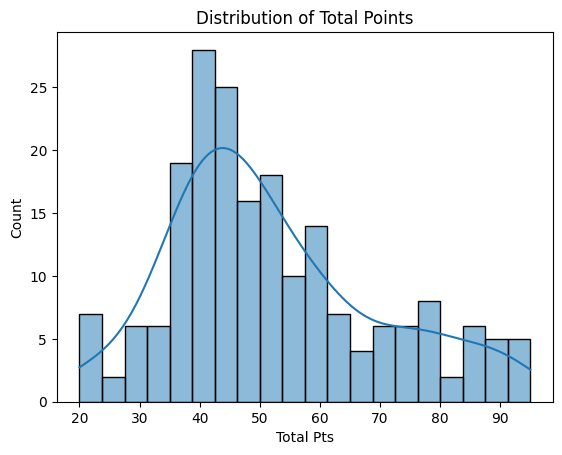

In [11]:
sns.histplot(df['Total Pts'], bins=20, kde=True)
plt.title('Distribution of Total Points')
plt.show()

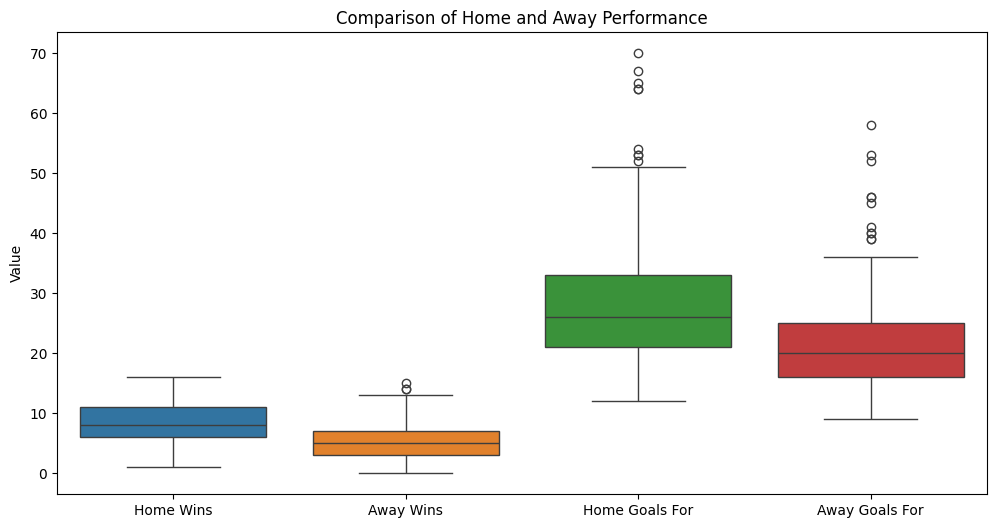

In [12]:
# Comparing Home and Away Stats

home_stats = ['HW', 'HL', 'HGF', 'HGA']
away_stats = ['AW', 'AL', 'AGF', 'AGA'] 

# Rename columns to make labels clearer
df_simple = df[['Squad', 'Season'] + home_stats + away_stats].copy()
df_simple = df_simple.rename(columns={
    'HW': 'Home Wins', 'HL': 'Home Losses', 'HGF': 'Home Goals For', 'HGA': 'Home Goals Against',
    'AW': 'Away Wins', 'AL': 'Away Losses', 'AGF': 'Away Goals For', 'AGA': 'Away Goals Against'
})

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_simple[["Home Wins", "Away Wins", "Home Goals For", "Away Goals For"]])

plt.title("Comparison of Home and Away Performance")
plt.ylabel("Value")
plt.show()

In [13]:
df[df['League Category'] == 'Champions']

,Season,Squad,FIFA OVR RATING,MP,TW,TD,TL,TGF,TGA,TGD,...,HW,HD,HL,HGF,HGA,AW,AD,AL,AGF,AGA
0,2023/2024,Real Madrid,85,38,29,8,1,87,26,61,...,16,3,0,48,9,13,5,1,39,17
20,2022/2023,Barcelona,83,38,28,4,6,70,20,50,...,15,3,1,37,4,13,1,5,33,16
40,2021/2022,Real Madrid,84,38,26,8,4,80,31,49,...,13,5,1,44,13,13,3,3,36,18
60,2020/2021,Atlético Madrid,83,38,26,8,4,67,25,42,...,15,3,1,41,11,11,5,3,26,14
80,2019/2020,Real Madrid,86,38,26,9,3,70,25,45,...,15,4,0,40,11,11,5,3,30,14
100,2018/2019,Barcelona,86,38,26,9,3,90,36,54,...,15,3,1,51,17,11,6,2,39,19
120,2017/2018,Barcelona,85,38,28,9,1,99,29,70,...,16,3,0,53,11,12,6,1,46,18
140,2016/2017,Real Madrid,86,38,29,6,3,106,41,65,...,14,4,1,48,20,15,2,2,58,21
160,2015/2016,Barcelona,84,38,29,4,5,112,29,83,...,16,1,2,67,14,13,3,3,45,15
180,2014/2015,Barcelona,84,38,30,4,4,110,21,89,...,16,1,2,64,11,14,3,2,46,10


In [14]:
champions_df = df[df['League Category'] == 'Champions']
champions_count = champions_df['Squad'].value_counts()
champions_count

Squad
 Barcelona          5
 Real Madrid        4
 Atlético Madrid    1
Name: count, dtype: int64

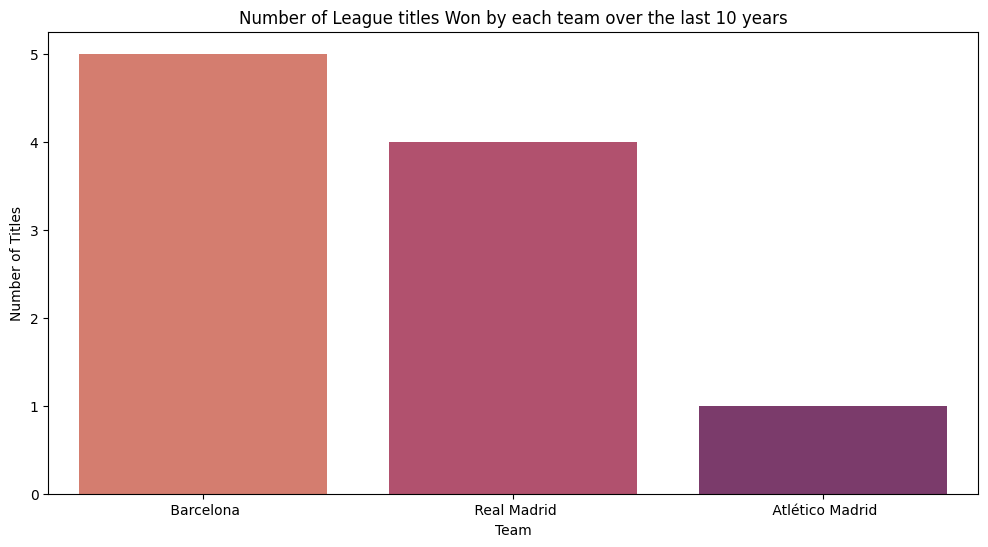

In [15]:
plt.figure(figsize=(12,6))

sns.barplot(x=champions_count.index, y=champions_count.values, palette='flare')
plt.xlabel('Team')
plt.ylabel('Number of Titles')
plt.title('Number of League titles Won by each team over the last 10 years')

plt.show()

In [16]:
champions_df

,Season,Squad,FIFA OVR RATING,MP,TW,TD,TL,TGF,TGA,TGD,...,HW,HD,HL,HGF,HGA,AW,AD,AL,AGF,AGA
0,2023/2024,Real Madrid,85,38,29,8,1,87,26,61,...,16,3,0,48,9,13,5,1,39,17
20,2022/2023,Barcelona,83,38,28,4,6,70,20,50,...,15,3,1,37,4,13,1,5,33,16
40,2021/2022,Real Madrid,84,38,26,8,4,80,31,49,...,13,5,1,44,13,13,3,3,36,18
60,2020/2021,Atlético Madrid,83,38,26,8,4,67,25,42,...,15,3,1,41,11,11,5,3,26,14
80,2019/2020,Real Madrid,86,38,26,9,3,70,25,45,...,15,4,0,40,11,11,5,3,30,14
100,2018/2019,Barcelona,86,38,26,9,3,90,36,54,...,15,3,1,51,17,11,6,2,39,19
120,2017/2018,Barcelona,85,38,28,9,1,99,29,70,...,16,3,0,53,11,12,6,1,46,18
140,2016/2017,Real Madrid,86,38,29,6,3,106,41,65,...,14,4,1,48,20,15,2,2,58,21
160,2015/2016,Barcelona,84,38,29,4,5,112,29,83,...,16,1,2,67,14,13,3,3,45,15
180,2014/2015,Barcelona,84,38,30,4,4,110,21,89,...,16,1,2,64,11,14,3,2,46,10


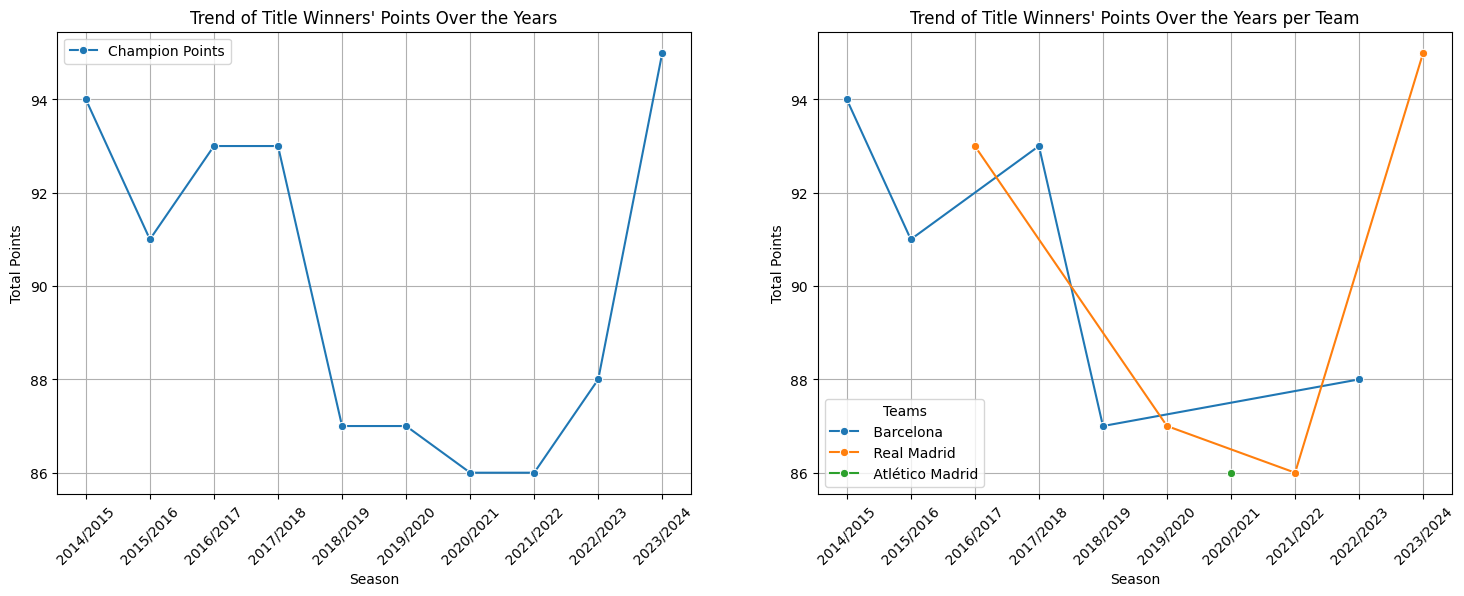

In [17]:
champions_df = df[df['Final Position'] == 1]
champions_df = champions_df.sort_values('Season')

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(x=champions_df['Season'], y=champions_df['Total Pts'], marker='o', label='Champion Points', ax=axs[0])
axs[0].set_xlabel("Season")
axs[0].set_ylabel("Total Points")
axs[0].set_title("Trend of Title Winners' Points Over the Years")
axs[0].set_xticklabels(champions_df['Season'], rotation=45)
axs[0].grid(True)

sns.lineplot(x=champions_df['Season'], y=champions_df["Total Pts"], hue=champions_df["Squad"], marker="o", ax=axs[1])
axs[1].set_xlabel("Season")
axs[1].set_ylabel("Total Points")
axs[1].set_title("Trend of Title Winners' Points Over the Years per Team")
axs[1].set_xticklabels(champions_df['Season'], rotation=45)
axs[1].grid(True)
axs[1].legend(title="Teams")

plt.show()

In [18]:
# From the two graphs above, it shows it takes at least 86 points to win LaLiga over the past 10 years

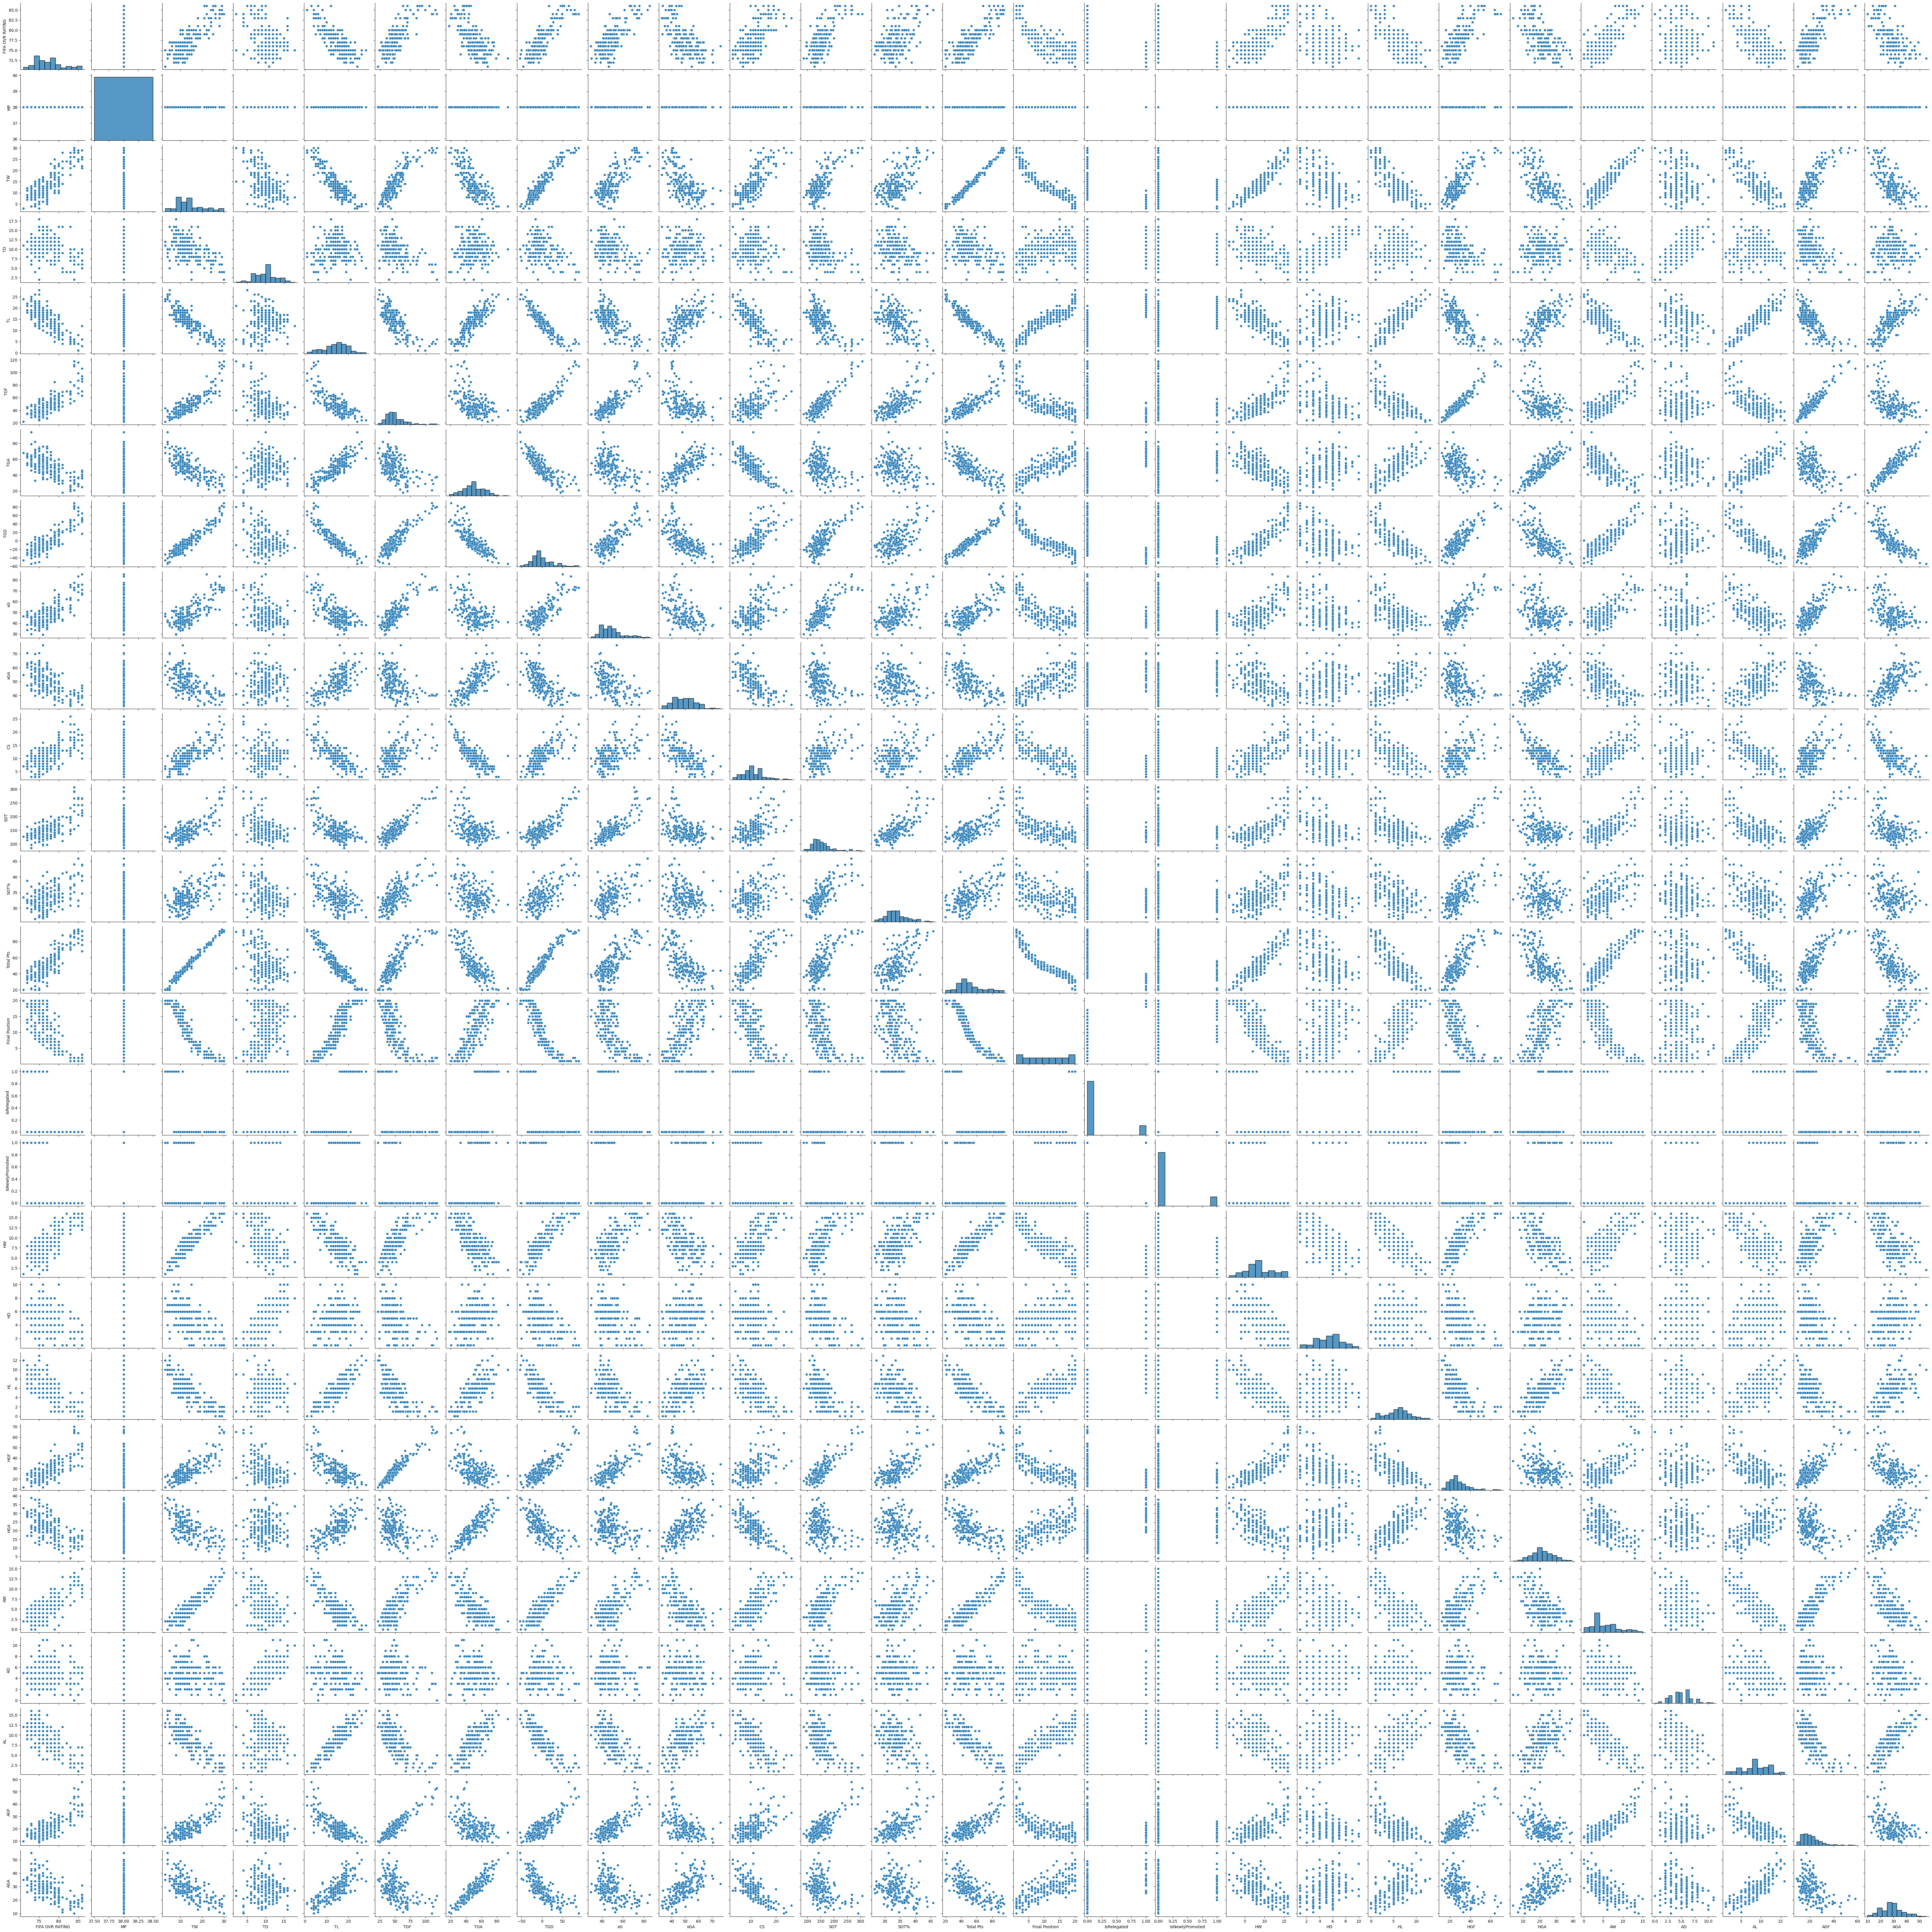

In [19]:
sns.pairplot(data=df)

plt.show()

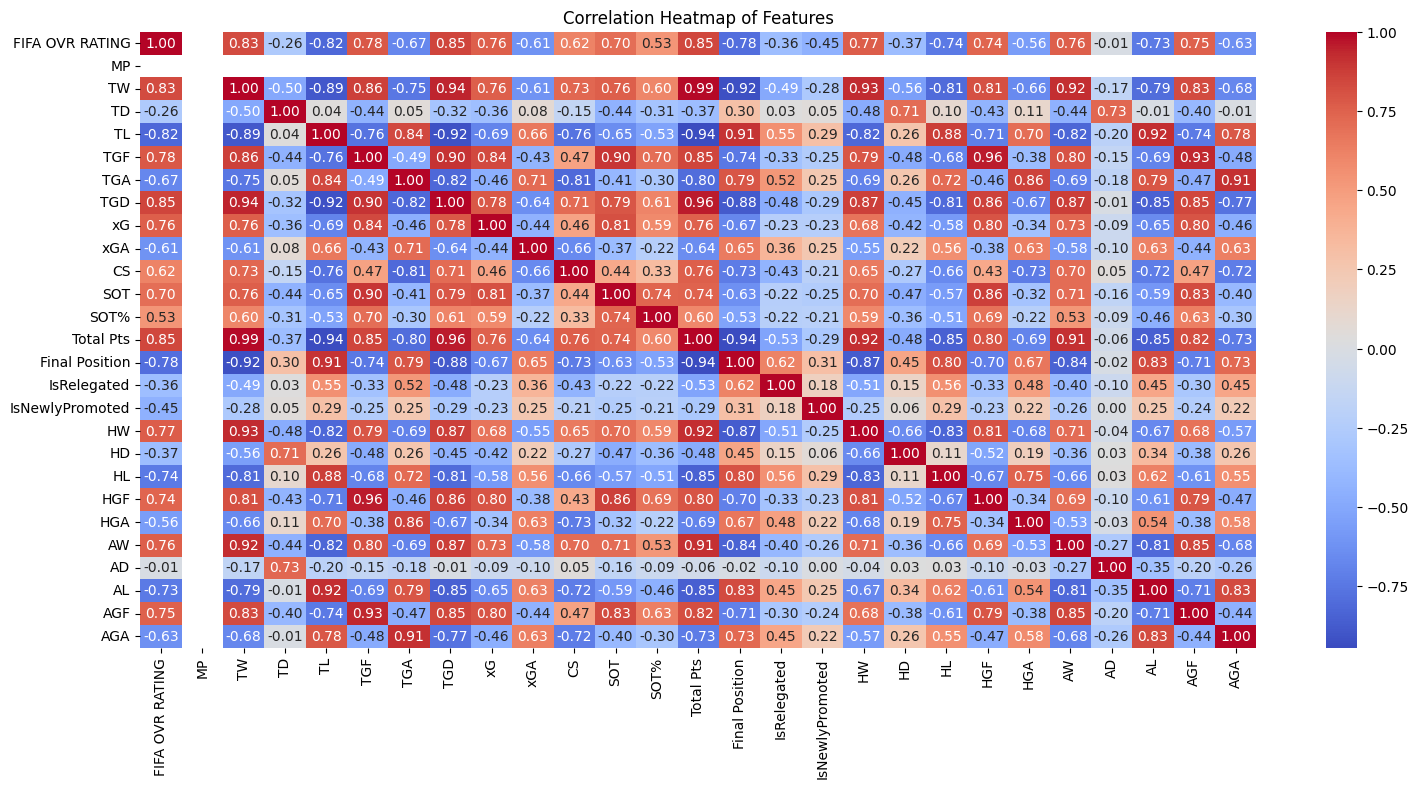

In [20]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numerical_df.corr()

plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Features')

plt.show()

## Feature Selection

In [30]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFE

In [31]:
# Dropping categorical columns and target columns
X = df.drop(columns=['Season', 'Squad', 'Total Pts', 'League Category', 'Final Position'])
y_regression = df['Total Pts']
y_classification = df['League Category']

# Regression Feature Selection
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rfe_reg = RFE(rf_reg, n_features_to_select=10)
X_selected_reg = rfe_reg.fit_transform(X, y_regression)
selected_features_reg = X.columns[rfe_reg.support_]

# Classification Feature Selection
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe_clf = RFE(rf_clf, n_features_to_select=10)
X_selected_clf = rfe_clf.fit_transform(X, y_classification)
selected_features_clf = X.columns[rfe_clf.support_]

# Showing the selected features
print("\nSelected Features for Final Position (Regression):", selected_features_reg)
print("\nSelected Features for League Category (Classification):", selected_features_clf)


Selected Features for Final Position (Regression): Index(['TW', 'TL', 'TGA', 'TGD', 'xGA', 'IsRelegated', 'HL', 'AW', 'AL',
       'AGF'],
      dtype='object')

Selected Features for League Category (Classification): Index(['FIFA OVR RATING', 'TW', 'TL', 'TGF', 'TGA', 'TGD', 'IsRelegated', 'HW',
       'HL', 'AW'],
      dtype='object')


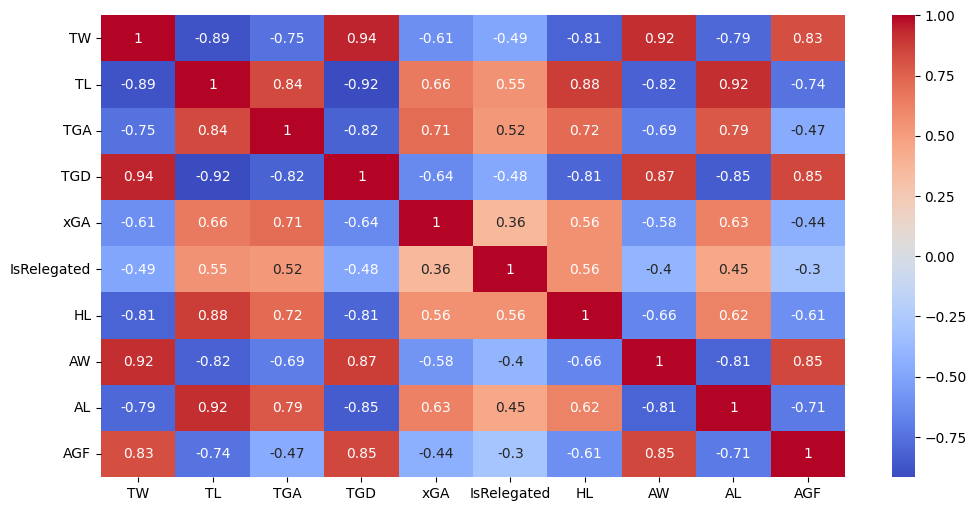

In [32]:
df_reg = df[selected_features_reg]

plt.figure(figsize=(12,6))
sns.heatmap(df_reg.corr(), annot=True, cmap='coolwarm')
plt.show()

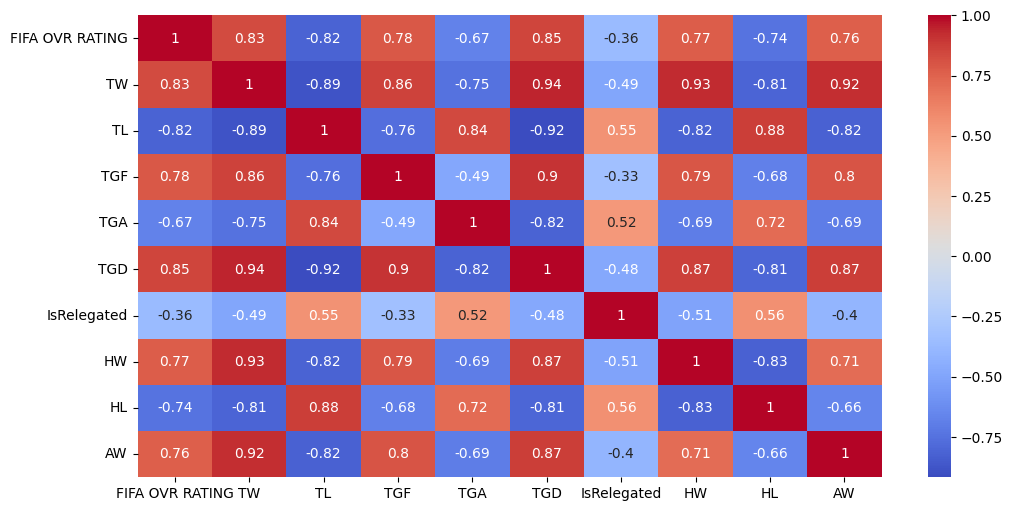

In [33]:
df_clf = df[selected_features_clf]

plt.figure(figsize=(12,6))
sns.heatmap(df_clf.corr(), annot=True, cmap='coolwarm')
plt.show()

## Preparing Data for Training

In [34]:
# Splitting based on season and not using train test split because train_test_split would randomly shuffle teams from all seasons and model might not understand what it's trying to train

In [35]:
# Sort seasons chronologically (oldest to newest)
seasons = sorted(df['Season'].unique())

# Train on first 8, test on last 2
train_seasons = seasons[:8]  # 2014/15 to 2021/22
test_seasons = seasons[8:]   # 2022/23 and 2023/24

# Regression
df_train_reg = df[df['Season'].isin(train_seasons)]
df_test_reg = df[df['Season'].isin(test_seasons)]

X_train_reg = df_train_reg[selected_features_reg]
y_train_reg = df_train_reg['Total Pts']
X_test_reg = df_test_reg[selected_features_reg]
y_test_reg = df_test_reg['Total Pts']

# Classification
df_train_clf = df[df['Season'].isin(train_seasons)]
df_test_clf = df[df['Season'].isin(test_seasons)]

X_train_clf = df_train_clf[selected_features_clf]
y_train_clf = df_train_clf['League Category']
X_test_clf = df_test_clf[selected_features_clf]
y_test_clf = df_test_clf['League Category']


In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Regression
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

# Classification
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)


## ANN

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_reg_scaled.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

In [38]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [39]:
early_stop = EarlyStopping(patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_ann_model.keras", save_best_only=True)

In [40]:
history = model.fit(
    X_train_reg_scaled, y_train_reg,
    validation_split=0.1,
    epochs=200,
    batch_size=8,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 3239.7339 - mae: 53.9097 - val_loss: 1980.1475 - val_mae: 42.5435
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2715.5852 - mae: 49.6300 - val_loss: 1536.2874 - val_mae: 36.8380
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2037.2887 - mae: 41.6946 - val_loss: 534.2771 - val_mae: 19.4862
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 927.1359 - mae: 24.5508 - val_loss: 383.9579 - val_mae: 16.3721
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 301.3606 - mae: 14.4744 - val_loss: 219.7937 - val_mae: 12.7761
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 211.8289 - mae: 11.8444 - val_loss: 131.9335 - val_mae: 10.1308
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 135.7095 - mae: 8.9286 - val_loss: 88.2732 - val_mae: 8.4003
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 93.4839 - mae: 7.8697 - val_loss: 46.2151 - val_mae: 6.0936
Epoch 9/200
18/18

In [41]:
# Evaluate Model
y_pred = model.predict(X_test_reg_scaled).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


In [42]:
# Model Evaluation

mse = mean_squared_error(y_test_reg, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

print(f"\n Evaluation Metrics:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.3f}")


 Evaluation Metrics:
RMSE: 1.32
MAE: 0.96
R² Score: 0.994


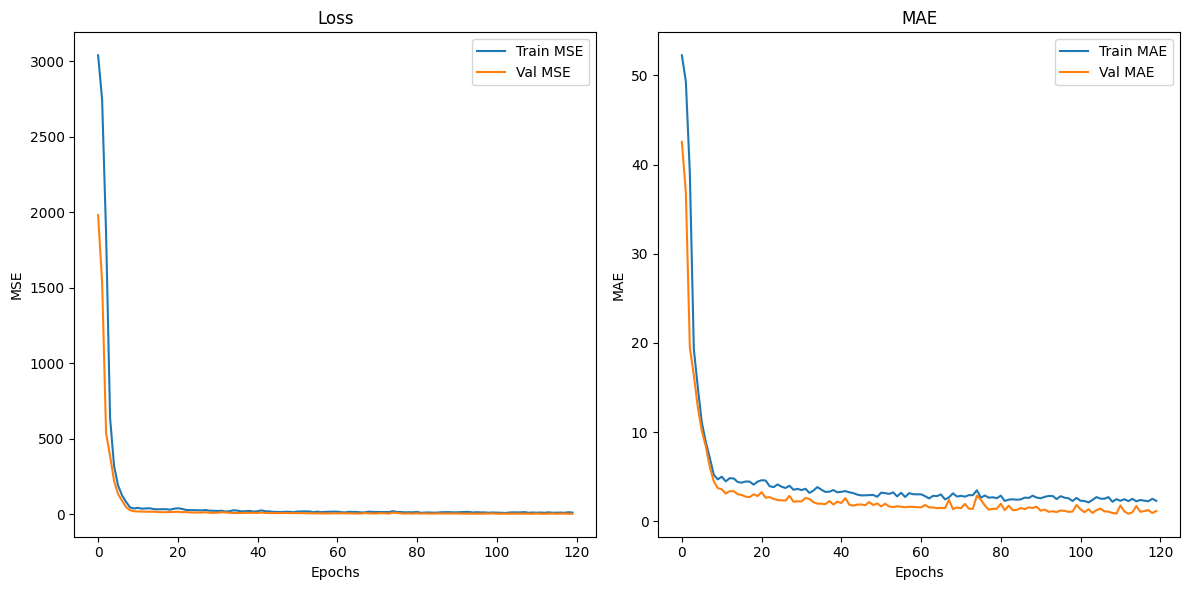

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()

# MAE Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title("MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()


In [44]:
# Predicted Points

y_pred = model.predict(X_test_reg_scaled).flatten()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [45]:
test_df = df[df['Season'].isin(test_seasons)].copy()
test_df['Predicted Pts'] = y_pred
test_df['Predicted Pts'] = test_df['Predicted Pts'].round().astype(int)

In [46]:
for season in sorted(test_df['Season'].unique(), reverse=True):
    print(f"\nSeason: {season}")
    season_data = test_df[test_df['Season'] == season].copy()

    # Actual Standings
    actual_table = season_data.sort_values(by='Total Pts', ascending=False)
    actual_table['Actual Rank'] = range(1, len(actual_table)+1)

    # Predicted Standings
    predicted_table = season_data.sort_values(by='Predicted Pts', ascending=False)
    predicted_table['Predicted Rank'] = range(1, len(predicted_table)+1)

    # Merge to compare
    comparison = actual_table[['Squad', 'Total Pts', 'Actual Rank']].merge(
        predicted_table[['Squad', 'Predicted Pts', 'Predicted Rank']],
        on='Squad'
    )

    display(comparison.sort_values(by='Actual Rank'))


Season: 2023/2024


,Squad,Total Pts,Actual Rank,Predicted Pts,Predicted Rank
0,Real Madrid,95,1,94,1
1,Barcelona,85,2,82,2
2,Girona,81,3,81,3
3,Atlético Madrid,76,4,75,4
4,Athletic Club,68,5,69,5
5,Real Sociedad,60,6,60,6
6,Betis,57,7,56,7
7,Villarreal,53,8,54,8
8,Valencia,49,9,49,9
9,Alavés,46,10,45,11



Season: 2022/2023


,Squad,Total Pts,Actual Rank,Predicted Pts,Predicted Rank
0,Barcelona,88,1,88,1
1,Real Madrid,78,2,79,2
2,Atlético Madrid,77,3,77,3
3,Real Sociedad,71,4,70,4
4,Villarreal,64,5,64,5
5,Betis,60,6,60,6
6,Osasuna,53,7,51,7
7,Athletic Club,51,8,51,8
8,Mallorca,50,9,50,9
9,Sevilla,49,10,49,10


## XGBoost

In [47]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_reg_scaled, y_train_reg)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [48]:
xgb_preds = xgb_model.predict(X_test_reg_scaled)

In [49]:
# Model Evaluation

rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, xgb_preds))
mae_xgb = mean_absolute_error(y_test_reg, xgb_preds)
r2_xgb = r2_score(y_test_reg, xgb_preds)

print("XGBoost Evaluation Metrics:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R² Score: {r2_xgb:.3f}")

XGBoost Evaluation Metrics:
RMSE: 1.49
MAE: 0.93
R² Score: 0.993


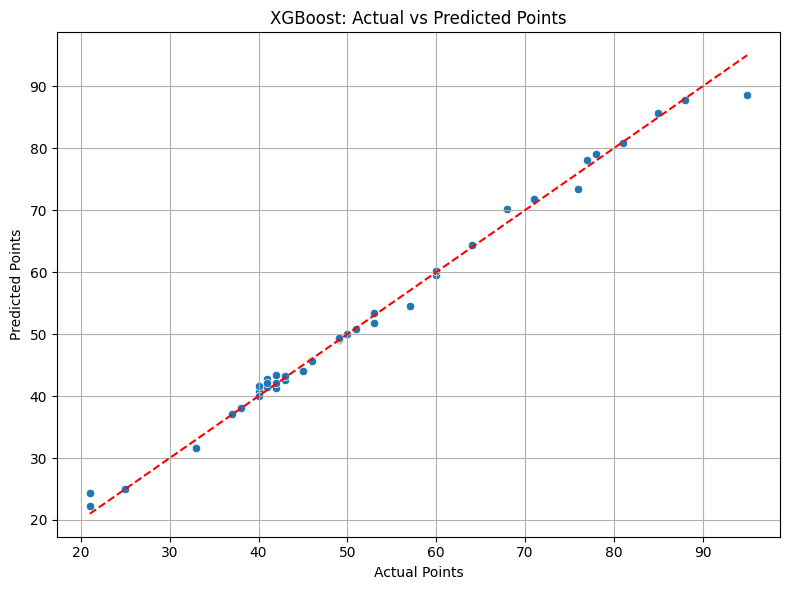

In [50]:
# Visualization: Actual vs Predicted

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_reg, y=xgb_preds)
plt.plot([min(y_test_reg), max(y_test_reg)], [min(y_test_reg), max(y_test_reg)], color='red', linestyle='--')
plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("XGBoost: Actual vs Predicted Points")
plt.grid(True)
plt.tight_layout()
plt.show()

In [51]:
# Add predictions to test_df
test_df['XGB Predicted Pts'] = xgb_preds.round().astype(int)

# For each test season, sort and compare
for season in sorted(test_df['Season'].unique(), reverse=True):
    print(f"\nXGBoost League Table — Season: {season}")
    season_data = test_df[test_df['Season'] == season].copy()

    # Actual Standings
    actual_table = season_data.sort_values(by='Total Pts', ascending=False)
    actual_table['Actual Rank'] = range(1, len(actual_table)+1)

    # Predicted Standings
    predicted_table = season_data.sort_values(by='XGB Predicted Pts', ascending=False)
    predicted_table['Predicted Rank'] = range(1, len(predicted_table)+1)

    # Merge to compare
    comparison = actual_table[['Squad', 'Total Pts', 'Actual Rank']].merge(
        predicted_table[['Squad', 'XGB Predicted Pts', 'Predicted Rank']],
        on='Squad'
    )

    display(comparison.sort_values(by='Actual Rank'))



XGBoost League Table — Season: 2023/2024


,Squad,Total Pts,Actual Rank,XGB Predicted Pts,Predicted Rank
0,Real Madrid,95,1,89,1
1,Barcelona,85,2,86,2
2,Girona,81,3,81,3
3,Atlético Madrid,76,4,73,4
4,Athletic Club,68,5,70,5
5,Real Sociedad,60,6,60,6
6,Betis,57,7,55,7
7,Villarreal,53,8,53,8
8,Valencia,49,9,49,9
9,Alavés,46,10,46,10



XGBoost League Table — Season: 2022/2023


,Squad,Total Pts,Actual Rank,XGB Predicted Pts,Predicted Rank
0,Barcelona,88,1,88,1
1,Real Madrid,78,2,79,2
2,Atlético Madrid,77,3,78,3
3,Real Sociedad,71,4,72,4
4,Villarreal,64,5,64,5
5,Betis,60,6,60,6
6,Osasuna,53,7,52,7
7,Athletic Club,51,8,51,8
8,Mallorca,50,9,50,9
9,Sevilla,49,10,49,10


## Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_clf_scaled, y_train_clf)

RandomForestClassifier(random_state=42)

In [69]:
y_pred_clf = rf_clf.predict(X_test_clf_scaled)

In [70]:
# Model Evaluation

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_test_clf, y_pred_clf)
print(f"Accuracy: {acc:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf))


Accuracy: 0.90

Classification Report:
                         precision    recall  f1-score   support

              Champions       1.00      0.50      0.67         2
  Champions League Spot       0.75      1.00      0.86         6
Europa/Conf League Spot       1.00      0.50      0.67         6
              Mid Table       0.91      1.00      0.95        20
              Relegated       1.00      1.00      1.00         6

               accuracy                           0.90        40
              macro avg       0.93      0.80      0.83        40
           weighted avg       0.92      0.90      0.89        40



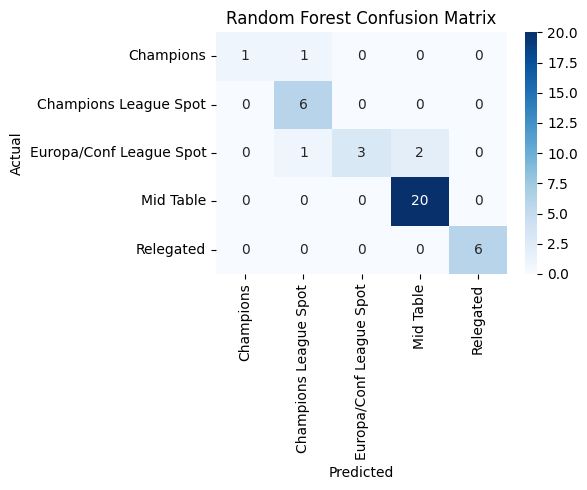

In [71]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=rf_clf.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
df_test_clf = df_test_clf.copy()
df_test_clf['RF Predicted Category'] = y_pred_clf

In [ ]:
for season in sorted(test_seasons, reverse=True):
    season_df = df_test_clf[df_test_clf['Season'] == season].copy()
    season_df = season_df[['Squad', 'League Category', 'RF Predicted Category']]
    season_df = season_df.sort_values(by='League Category').reset_index(drop=True)

    print(f"\n📊 League Category Prediction — {season}")
    display(season_df)



📊 League Category Prediction — 2023/2024


,Squad,League Category,RF Predicted Category
0,Real Madrid,Champions,Champions
1,Barcelona,Champions League Spot,Champions League Spot
2,Girona,Champions League Spot,Champions League Spot
3,Atlético Madrid,Champions League Spot,Champions League Spot
4,Athletic Club,Europa/Conf League Spot,Champions League Spot
5,Real Sociedad,Europa/Conf League Spot,Europa/Conf League Spot
6,Betis,Europa/Conf League Spot,Mid Table
7,Rayo Vallecano,Mid Table,Mid Table
8,Las Palmas,Mid Table,Mid Table
9,Mallorca,Mid Table,Mid Table



📊 League Category Prediction — 2022/2023


,Squad,League Category,RF Predicted Category
0,Barcelona,Champions,Champions League Spot
1,Real Madrid,Champions League Spot,Champions League Spot
2,Atlético Madrid,Champions League Spot,Champions League Spot
3,Real Sociedad,Champions League Spot,Champions League Spot
4,Villarreal,Europa/Conf League Spot,Europa/Conf League Spot
5,Betis,Europa/Conf League Spot,Europa/Conf League Spot
6,Osasuna,Europa/Conf League Spot,Mid Table
7,Almería,Mid Table,Mid Table
8,Valencia,Mid Table,Mid Table
9,Getafe,Mid Table,Mid Table


## SVM

In [75]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_clf.fit(X_train_clf, y_train_clf)

SVC(probability=True, random_state=42)

In [78]:
# Predict on test set
y_pred_svm = svm_clf.predict(X_test_clf)

In [79]:
# Accuracy
acc = accuracy_score(y_test_clf, y_pred_svm)
print(f"Accuracy: {acc:.2f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_svm))

Accuracy: 0.75

Classification Report:
                         precision    recall  f1-score   support

              Champions       0.00      0.00      0.00         2
  Champions League Spot       0.62      0.83      0.71         6
Europa/Conf League Spot       0.67      0.33      0.44         6
              Mid Table       0.77      1.00      0.87        20
              Relegated       1.00      0.50      0.67         6

               accuracy                           0.75        40
              macro avg       0.61      0.53      0.54        40
           weighted avg       0.73      0.75      0.71        40



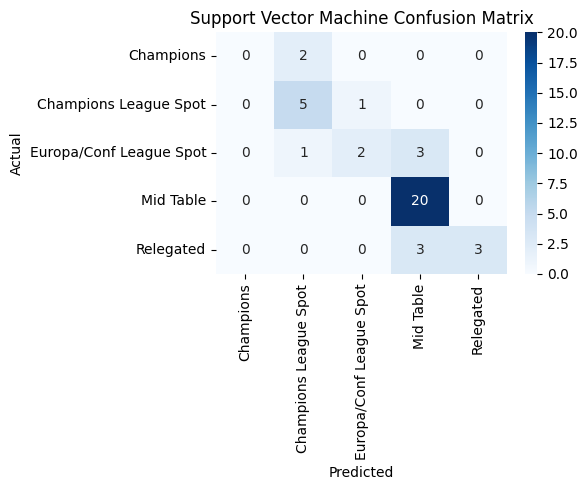

In [80]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_svm, labels=rf_clf.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=rf_clf.classes_, yticklabels=rf_clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Support Vector Machine Confusion Matrix")
plt.tight_layout()
plt.show()

In [81]:
df_test_clf = df_test_clf.copy()
df_test_clf['RF Predicted Category'] = y_pred_svm

In [82]:
for season in sorted(test_seasons, reverse=True):
    season_df = df_test_clf[df_test_clf['Season'] == season].copy()
    season_df = season_df[['Squad', 'League Category', 'RF Predicted Category']]
    season_df = season_df.sort_values(by='League Category').reset_index(drop=True)

    print(f"\nLeague Category Prediction — {season}")
    display(season_df)


League Category Prediction — 2023/2024


,Squad,League Category,RF Predicted Category
0,Real Madrid,Champions,Champions League Spot
1,Barcelona,Champions League Spot,Champions League Spot
2,Girona,Champions League Spot,Champions League Spot
3,Atlético Madrid,Champions League Spot,Champions League Spot
4,Athletic Club,Europa/Conf League Spot,Champions League Spot
5,Real Sociedad,Europa/Conf League Spot,Europa/Conf League Spot
6,Betis,Europa/Conf League Spot,Mid Table
7,Rayo Vallecano,Mid Table,Mid Table
8,Las Palmas,Mid Table,Mid Table
9,Mallorca,Mid Table,Mid Table



League Category Prediction — 2022/2023


,Squad,League Category,RF Predicted Category
0,Barcelona,Champions,Champions League Spot
1,Real Madrid,Champions League Spot,Champions League Spot
2,Atlético Madrid,Champions League Spot,Champions League Spot
3,Real Sociedad,Champions League Spot,Europa/Conf League Spot
4,Villarreal,Europa/Conf League Spot,Europa/Conf League Spot
5,Betis,Europa/Conf League Spot,Mid Table
6,Osasuna,Europa/Conf League Spot,Mid Table
7,Almería,Mid Table,Mid Table
8,Valencia,Mid Table,Mid Table
9,Getafe,Mid Table,Mid Table
